# Exploratory Data Analysis (EDA)

## Erasmus+ Traineeship – University of Cantabria

### Project
**Data Science Support for Sustainability Analysis in the Agri-food Sector**

### Supervisor
**Dr. Elisa Baraibar Díez**

### Student
**Ranim Hfaiedh**

### Notebook Objective

The objective of this notebook is to explore, understand, and evaluate the structure and quality of the combined agri-food company database. This exploratory analysis provides the foundation for subsequent data cleaning, descriptive statistics, sustainability analysis, and Natural Language Processing (NLP) techniques.

# 1. Import Required Libraries

This section imports the Python libraries that will be used throughout the notebook for data manipulation, numerical analysis, and data visualization.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", None)

# 2. Load the Dataset

The combined Excel database is uploaded into Google Colab and loaded into a Pandas DataFrame for exploratory analysis.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving DATABASE.xlsx to DATABASE.xlsx


In [3]:
# ==========================================
# Display workbook sheets
# ==========================================

excel_file = pd.ExcelFile("DATABASE.xlsx")

excel_file.sheet_names

['Combined', 'BigCompanies', '2-3-10', '014 to 017', '011 to 013']

In [4]:
# ==========================================
# Load the Combined sheet
# ==========================================

df = pd.read_excel(
    "DATABASE.xlsx",
    sheet_name="Combined"
)

In [5]:
# Display the first five rows

df.head()

,Column1,Company name,Street,Postal code,Locality,Province,Autonomous community,Phone number,Web address,Tax ID Code,Legal form,Share capital (thousand EUR),President,Executive Director,"Quotes, doesn't quote, quoted",Last available year,Number of available years,Latest employee count,Stock Market Quote,Operating revenue (thousand EUR),Nb of companies in corporate group,Number of investees,Primary CNAE 2009 code,Secondary code(s) CNAE 2009,Secondary literal(s) CNAE 2009,Primary CNAE 2009 code literal,Group name,Group Description,Group size,English trade description,Activity description,Importer / Exporter
0,1,GREENMED SL,"CALLE MANUEL VIVANCO, 12",12550.0,ALMASSORA,Castellón,Comunidad Valenciana,+34 96/1742700,www.greenmed.es,B12457230,Sociedad limitada,57,REVACITRUS SOCIEDAD LIMITADA,AGRIMARBA 2 SL,No cotiza en bolsa,2024-08-31,26,1292,No Cotiza en Bolsa,245291.0,0.0,0,123,4631.0,Comercio al por mayor de frutas y hortalizas,Cultivo de cítricos,012 VL,Cultivos perennes,1325,This company is primarily engaged in processin...,Comercialización de cítricos,Exportador
1,2,AGROPONIENTE NATURAL PRODUCE SL,"CALLE PAISES BAJOS, 1",4710.0,EL EJIDO,Almería,Andalucía,+34 95/0583002,www.agroponiente.com,B04172862,Sociedad limitada,392,NaN,Don Jorge Reig Berlanga,No cotiza en bolsa,2025-08-31,24,1293,No Cotiza en Bolsa,244386.0,33.0,3,113,4631.0,Comercio al por mayor de frutas y hortalizas,"Cultivo de hortalizas, raíces y tubérculos",011 VL,Cultivos no perennes,1151,This company is engaged in the production and ...,Comercialización de productos hortofruticolas.,Importador / Exportador
2,3,"BORGES AGRICULTURAL & INDUSTRIAL NUTS, S.A. (E...","CALLE FLIX, 29",43205.0,REUS,Tarragona,Cataluña,+34 97/7309000,www.borges-bain.com,A58410804,Sociedad anonima,9950,NaN,NaN,Dejó de cotizar en bolsa,2020-05-31,22,311,No Cotiza en Bolsa,175768.0,0.0,0,125,127.0,Cultivo de plantas para bebidas,Cultivo de otros árboles y arbustos frutales y...,012,Cultivos perennes,18566,The company is an entity based in Spain that p...,"Producción, procesado y comercialización de fr...",No realiza actividad exterior
3,4,AROFA SL,"CALLE PAULINO CABALLERO, 23",31003.0,PAMPLONA/IRUÑA,Navarra,Navarra,+34 94/8151096,www.arofa.com,B31406721,Sociedad limitada,1000,Don Domingo Arotzarena Marin,Don Francisco Arotzarena Marin,No cotiza en bolsa,2024-12-31,29,227,No Cotiza en Bolsa,146663.0,5.0,6,125,161.0,Actividades de apoyo a la agricultura,Cultivo de otros árboles y arbustos frutales y...,012 VL,Cultivos perennes,1325,This company is engaged in the export and whol...,"Cultivo, procesamiento, crecimiento, desarroll...",Importador / Exportador
4,5,LICUAS SA,"CALLE NANCLARES DE OCA (EDIF. ""A2 PLAZA"" FASE ...",28022.0,MADRID,Madrid,Madrid,+34 91/3531050,www.licuas.es,A78066487,Sociedad anonima,4405,Don Joaquin Molpeceres Sanchez,Don Eduardo Rojas Martin,No cotiza en bolsa,2024-12-31,33,1045,No Cotiza en Bolsa,112302.0,17.0,30,130,8020.0,Servicios de sistemas de seguridad,Propagación de plantas,013 VL,Propagación de plantas,51,This company is engaged in the provision of co...,"La construcción o instalación, mantenimiento y...",Importador / Exportador


In [6]:
df.columns.tolist()

['Column1',
 'Company name',
 'Street',
 'Postal code',
 'Locality',
 'Province',
 'Autonomous community',
 'Phone number',
 'Web address',
 'Tax ID Code',
 'Legal form',
 'Share capital (thousand EUR)',
 'President',
 'Executive Director',
 "Quotes, doesn't quote, quoted",
 'Last available year',
 'Number of available years',
 'Latest employee count',
 'Stock Market Quote',
 'Operating revenue (thousand EUR)',
 'Nb of companies in corporate group',
 'Number of investees',
 'Primary CNAE 2009 code',
 'Secondary code(s) CNAE 2009',
 'Secondary literal(s) CNAE 2009',
 'Primary CNAE 2009 code literal',
 'Group name',
 'Group Description',
 'Group size',
 'English trade description',
 'Activity description',
 'Importer / Exporter']

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the first stage of any data science project. Its purpose is to understand the structure, quality, and characteristics of the dataset before performing descriptive statistics, data cleaning, and advanced analyses.

## 3.1 Dataset Dimensions

This section examines the size of the dataset by identifying the total number of observations (rows) and variables (columns).

In [7]:
# ==========================================
# Dataset dimensions
# ==========================================

rows, columns = df.shape

print(f"Number of companies (rows): {rows}")
print(f"Number of variables (columns): {columns}")

Number of companies (rows): 72887
Number of variables (columns): 32


### Interpretation

The combined dataset contains **72,887 companies** and **32 variables**. This confirms that the dataset provides a comprehensive representation of Spanish agri-food companies and constitutes a solid foundation for the descriptive and sustainability analyses conducted in this project.

## 3.2 Dataset Variables

This section lists all variables available in the dataset and provides an overview of the information collected for each company.

In [8]:
# ==========================================
# Display column names
# ==========================================

df.columns.tolist()

['Column1',
 'Company name',
 'Street',
 'Postal code',
 'Locality',
 'Province',
 'Autonomous community',
 'Phone number',
 'Web address',
 'Tax ID Code',
 'Legal form',
 'Share capital (thousand EUR)',
 'President',
 'Executive Director',
 "Quotes, doesn't quote, quoted",
 'Last available year',
 'Number of available years',
 'Latest employee count',
 'Stock Market Quote',
 'Operating revenue (thousand EUR)',
 'Nb of companies in corporate group',
 'Number of investees',
 'Primary CNAE 2009 code',
 'Secondary code(s) CNAE 2009',
 'Secondary literal(s) CNAE 2009',
 'Primary CNAE 2009 code literal',
 'Group name',
 'Group Description',
 'Group size',
 'English trade description',
 'Activity description',
 'Importer / Exporter']

### Interpretation

The dataset includes variables describing company identification, geographical location, legal characteristics, financial information, economic activity, corporate structure, and international trade. These variables will support the descriptive statistical analyses and the subsequent sustainability assessment.

## 3.3 Dataset Information

This section examines the structure of the dataset, including the data type of each variable and the number of non-missing observations.

In [9]:
# ==========================================
# Dataset information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72887 entries, 0 to 72886
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Column1                             72887 non-null  int64         
 1   Company name                        72887 non-null  object        
 2   Street                              72884 non-null  object        
 3   Postal code                         72814 non-null  float64       
 4   Locality                            72886 non-null  object        
 5   Province                            72887 non-null  object        
 6   Autonomous community                72887 non-null  object        
 7   Phone number                        33800 non-null  object        
 8   Web address                         11755 non-null  object        
 9   Tax ID Code                         72887 non-null  object        
 10  Legal form            

### Interpretation

The dataset contains a combination of categorical, numerical, and textual variables. The information provided by the `info()` function allows us to evaluate data completeness and identify variables that may require additional preprocessing before analysis.

## 3.4 Missing Values

This section identifies missing values in each variable of the dataset. Detecting missing data is essential for evaluating data quality and determining whether preprocessing or cleaning is required before analysis.

In [10]:
# ==========================================
# Missing values
# ==========================================

missing_values = df.isnull().sum()

missing_values

,0
Column1,0
Company name,0
Street,3
Postal code,73
Locality,1
Province,0
Autonomous community,0
Phone number,39087
Web address,61132
Tax ID Code,0


In [11]:
# ==========================================
# Missing values percentage
# ==========================================

missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_summary.sort_values(by="Percentage (%)", ascending=False)

,Missing Values,Percentage (%)
English trade description,68430,93.89
President,68279,93.68
Web address,61132,83.87
Phone number,39087,53.63
Executive Director,27303,37.46
Secondary code(s) CNAE 2009,25752,35.33
Secondary literal(s) CNAE 2009,25752,35.33
Operating revenue (thousand EUR),9762,13.39
Activity description,3932,5.39
Postal code,73,0.10


### Interpretation

The missing value analysis indicates that most of the key variables related to company identification, legal characteristics, geographical location, and financial information are complete. However, some variables, such as website, telephone number, president, executive director, and English trade description, contain a substantial proportion of missing values. These findings will be considered during the data cleaning stage.

## 3.5 Duplicate Records

This section verifies whether duplicate observations exist in the dataset to ensure that each row represents a unique company.

In [12]:
# ==========================================
# Duplicate records
# ==========================================

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


### Interpretation

The duplicate analysis confirms that the dataset does not contain duplicate records. Therefore, each row corresponds to a unique company, and no duplicate removal is required.

# 4. Descriptive Analytics

This section presents a descriptive statistical analysis of the Spanish agri-food companies included in the combined dataset. The analyses summarize the geographical distribution, legal characteristics, economic activity, employment, financial indicators, and international trade activity of the companies.

## 4.1 Total Number of Companies

This section reports the total number of companies included in the combined database.

In [13]:
# ==========================================
# Total number of companies
# ==========================================

total_companies = len(df)

print(f"Total number of companies: {total_companies:,}")

Total number of companies: 72,887


### Interpretation

The combined dataset contains **72,887 Spanish agri-food companies**, providing a comprehensive basis for the descriptive statistical analysis and the subsequent sustainability assessment.

## 4.2 Companies by Autonomous Community

This analysis examines the geographical distribution of companies across the Spanish Autonomous Communities.

In [14]:
# ==========================================
# Companies by Autonomous Community
# ==========================================

companies_region = (
    df["Autonomous community"]
    .value_counts()
    .sort_values(ascending=False)
)

companies_region

,count
Autonomous community,
Andalucía,16274
Cataluña,8955
Comunidad Valenciana,5967
Castilla-La Mancha,5911
Castilla y León,5856
Madrid,5645
Galicia,5000
Murcia,4040
Aragón,4016


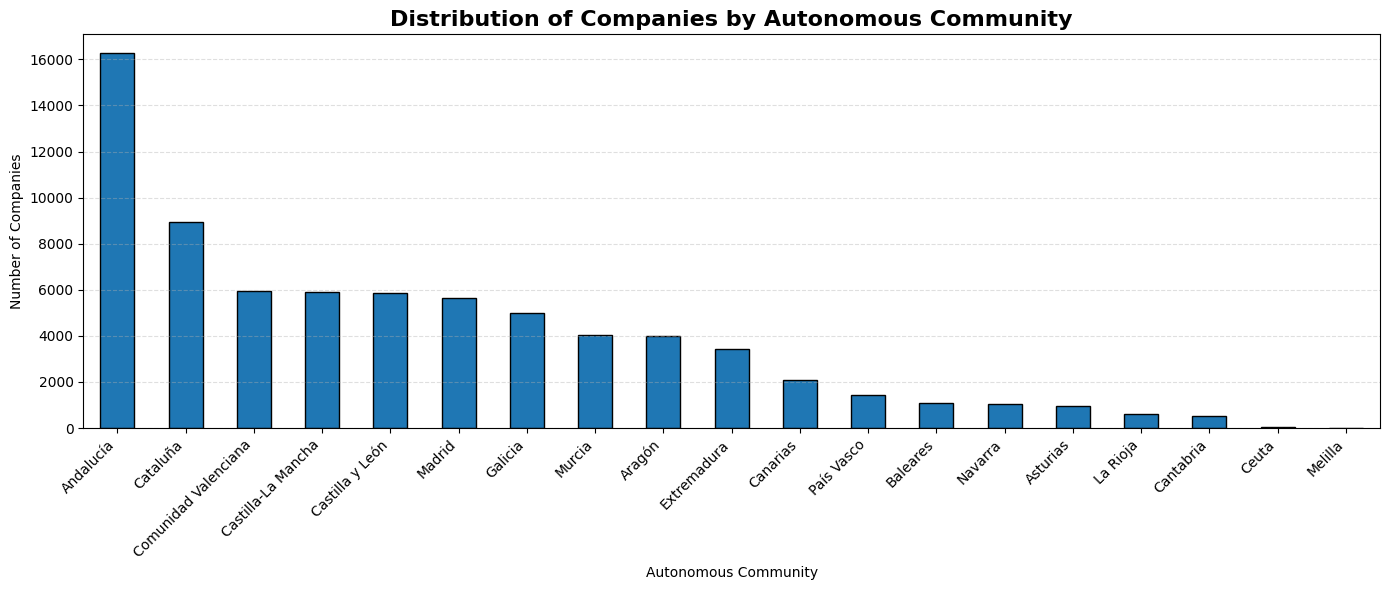

In [15]:
plt.figure(figsize=(14,6))

companies_region.plot(
    kind="bar",
    edgecolor="black"
)

plt.title(
    "Distribution of Companies by Autonomous Community",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Autonomous Community")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [16]:
companies_region.to_frame(name="Number of Companies")

,Number of Companies
Autonomous community,
Andalucía,16274
Cataluña,8955
Comunidad Valenciana,5967
Castilla-La Mancha,5911
Castilla y León,5856
Madrid,5645
Galicia,5000
Murcia,4040
Aragón,4016


In [17]:
region_summary = pd.DataFrame({
    "Number of Companies": companies_region,
    "Percentage (%)": round(companies_region / companies_region.sum() * 100, 2)
})

region_summary

,Number of Companies,Percentage (%)
Autonomous community,,
Andalucía,16274,22.33
Cataluña,8955,12.29
Comunidad Valenciana,5967,8.19
Castilla-La Mancha,5911,8.11
Castilla y León,5856,8.03
Madrid,5645,7.74
Galicia,5000,6.86
Murcia,4040,5.54
Aragón,4016,5.51


### Key Findings

- Andalucía contains the largest number of agri-food companies.
- Cataluña ranks second.
- The distribution of companies is highly concentrated in a few Autonomous Communities.
- Smaller regions such as Ceuta and Melilla contribute only a very small share of the dataset.

## 4.3 Companies by Legal Form

This section examines the distribution of companies according to their legal form.

In [18]:
# ==========================================
# Companies by Legal Form
# ==========================================

legal_form = df["Legal form"].value_counts()

legal_form

,count
Legal form,
Sociedad limitada,63906
Sociedad anonima,5756
Cooperativa,2469
Otros tipos no definidos,573
Asociación,69
Sociedad civil,64
Unión temporal de empresas,18
Sociedad regular colectiva,9
Establecimiento permanente de entidad no residente,7


In [19]:
legal_form_summary = pd.DataFrame({
    "Number of Companies": legal_form,
    "Percentage (%)": round(legal_form / legal_form.sum() * 100, 2)
})

legal_form_summary

,Number of Companies,Percentage (%)
Legal form,,
Sociedad limitada,63906,87.68
Sociedad anonima,5756,7.90
Cooperativa,2469,3.39
Otros tipos no definidos,573,0.79
Asociación,69,0.09
Sociedad civil,64,0.09
Unión temporal de empresas,18,0.02
Sociedad regular colectiva,9,0.01
Establecimiento permanente de entidad no residente,7,0.01


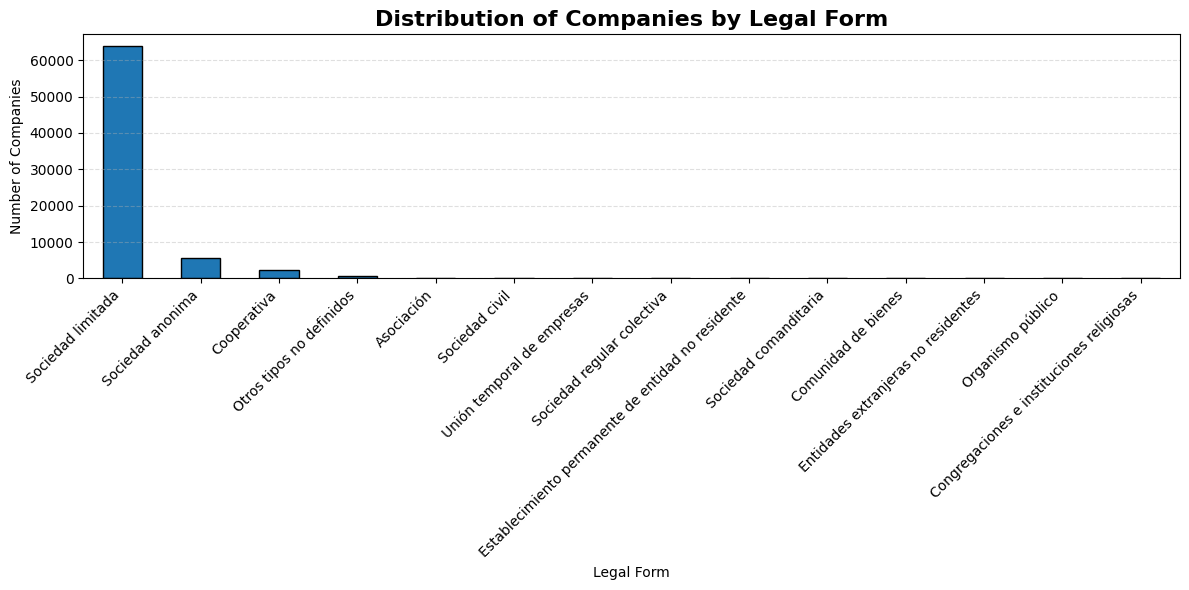

In [20]:
plt.figure(figsize=(12,6))

legal_form.plot(
    kind="bar",
    edgecolor="black"
)

plt.title(
    "Distribution of Companies by Legal Form",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Legal Form")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The results show that **Sociedad Limitada** is the most common legal form among the companies in the dataset, followed by **Sociedad Anónima**. All other legal forms represent only a small proportion of the companies.

## 4.3 Companies by Province

This section analyses the geographical distribution of companies across Spanish provinces. To improve readability, only the twenty provinces with the highest number of companies are presented.

In [21]:
# ==========================================
# Top 20 provinces
# ==========================================

province_counts = df["Province"].value_counts()

province_summary = pd.DataFrame({
    "Number of Companies": province_counts,
    "Percentage (%)": round(province_counts / len(df) * 100, 2)
})

province_summary.head(20)

,Number of Companies,Percentage (%)
Province,,
Madrid,5645,7.74
Sevilla,4093,5.62
Murcia,4040,5.54
Barcelona,3985,5.47
Valencia,2893,3.97
Almería,2487,3.41
Badajoz,2422,3.32
Lleida,2222,3.05
Córdoba,2123,2.91


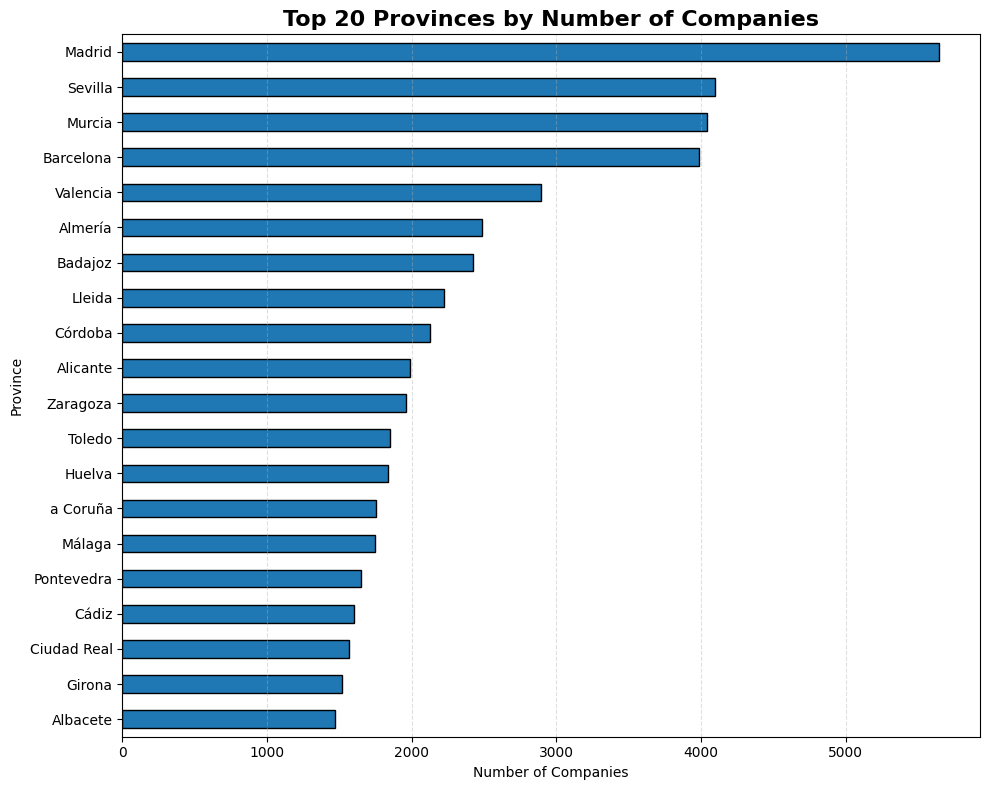

In [22]:
plt.figure(figsize=(10,8))

province_counts.head(20).sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title(
    "Top 20 Provinces by Number of Companies",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Companies")
plt.ylabel("Province")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The results show that the distribution of agri-food companies is concentrated in a limited number of Spanish provinces. Madrid has the highest number of companies, followed by Sevilla, Murcia, Barcelona, and Valencia. The remaining provinces in the top 20 have progressively fewer companies, indicating geographical differences in the distribution of the agri-food sector.

## 4.4 Companies by Economic Activity

This section analyses the distribution of companies according to their primary economic activity based on the CNAE 2009 classification. The analysis provides an overview of the main business activities represented in the dataset.

In [23]:
# ==========================================
# Companies by Economic Activity
# ==========================================

activity = df["Primary CNAE 2009 code literal"].value_counts()

activity.head(20)

,count
Primary CNAE 2009 code literal,
Fabricación de pan y de productos frescos de panadería y pastelería,6735
Actividades de apoyo a la agricultura,6447
Producción agrícola combinada con la producción ganadera,5629
"Cultivo de hortalizas, raíces y tubérculos",4334
"Cultivo de cereales (excepto arroz), leguminosas y semillas oleaginosas",4202
Explotación de ganado porcino,3413
Elaboración de productos cárnicos y de volatería,2841
Otros cultivos no perennes,2618
Pesca marina,2167


In [24]:
activity_summary = pd.DataFrame({
    "Number of Companies": activity.head(20),
    "Percentage (%)": round(activity.head(20) / len(df) * 100, 2)
})

activity_summary

,Number of Companies,Percentage (%)
Primary CNAE 2009 code literal,,
Fabricación de pan y de productos frescos de panadería y pastelería,6735,9.24
Actividades de apoyo a la agricultura,6447,8.85
Producción agrícola combinada con la producción ganadera,5629,7.72
"Cultivo de hortalizas, raíces y tubérculos",4334,5.95
"Cultivo de cereales (excepto arroz), leguminosas y semillas oleaginosas",4202,5.77
Explotación de ganado porcino,3413,4.68
Elaboración de productos cárnicos y de volatería,2841,3.90
Otros cultivos no perennes,2618,3.59
Pesca marina,2167,2.97


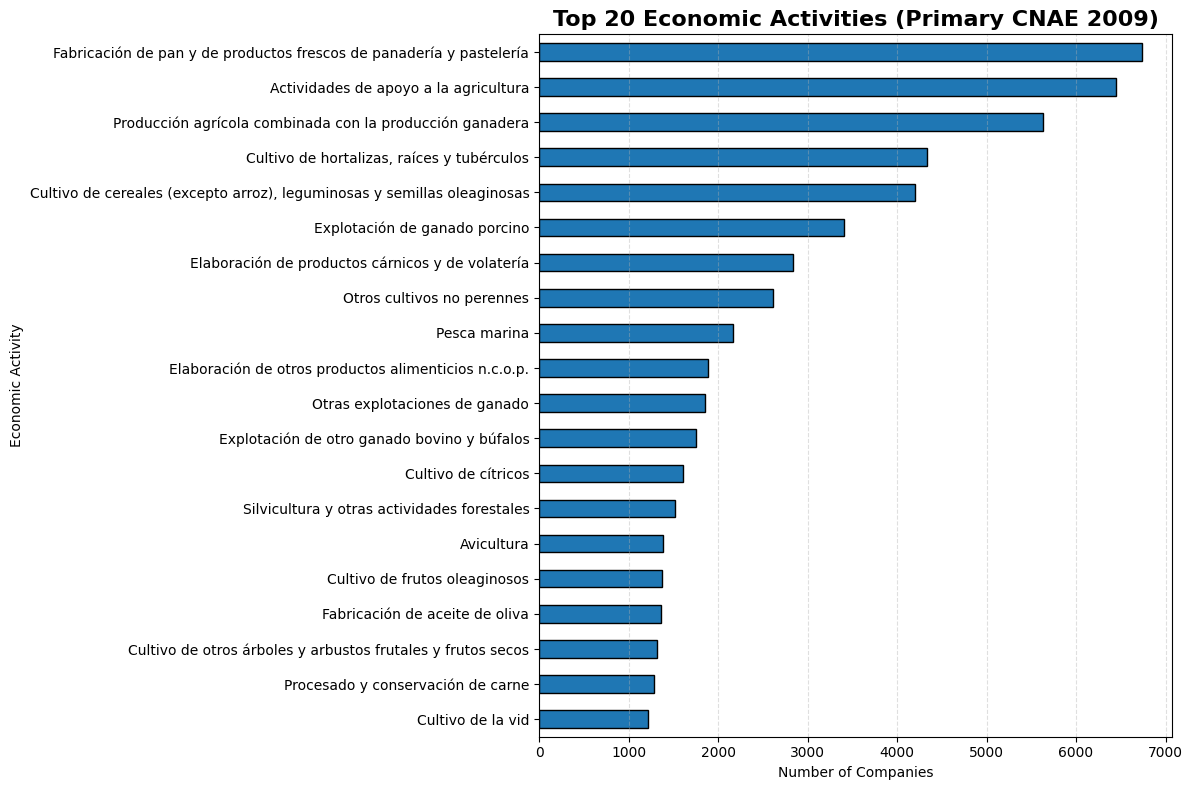

In [25]:
plt.figure(figsize=(12,8))

activity.head(20).sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title(
    "Top 20 Economic Activities (Primary CNAE 2009)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Companies")
plt.ylabel("Economic Activity")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The analysis shows that the Spanish agri-food sector is characterized by a diverse range of economic activities. The most represented activities include the manufacture of bakery and pastry products, agricultural support activities, mixed crop and livestock farming, and the cultivation of vegetables and cereals. This distribution highlights the diversity of production and processing activities within the sector.

## 4.5 Distribution of Employees

This section examines the distribution of the latest employee count across the companies included in the dataset. Company size is an important characteristic for understanding the structure of the agri-food sector.

In [26]:
# ==========================================
# Employee statistics
# ==========================================

df["Latest employee count"].describe()

,Latest employee count
count,72887.000000
mean,11.057267
std,62.400027
min,0.000000
25%,1.000000
50%,2.000000
75%,7.000000
max,5800.000000


### Employee Distribution

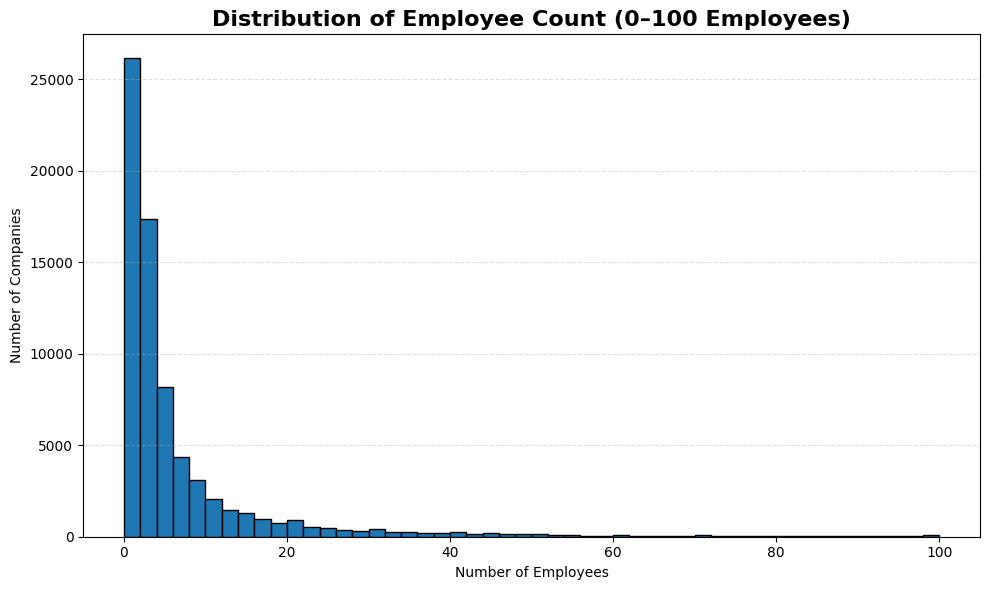

In [27]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Latest employee count"],
    bins=50,
    range=(0,100),
    edgecolor="black"
)

plt.title(
    "Distribution of Employee Count (0–100 Employees)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees")
plt.ylabel("Number of Companies")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The histogram shows that most companies in the dataset employ fewer than 20 employees, with the highest concentration observed among companies with fewer than five employees. As the number of employees increases, the number of companies decreases substantially, indicating that the Spanish agri-food sector is predominantly composed of small businesses.

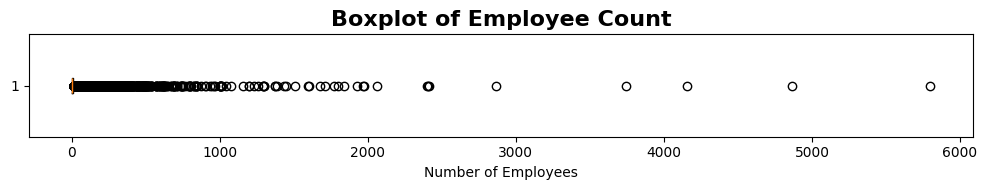

In [29]:
plt.figure(figsize=(10,2))

plt.boxplot(
    df["Latest employee count"],
    vert=False
)

plt.title(
    "Boxplot of Employee Count",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Employees")

plt.tight_layout()

plt.show()

### Interpretation

The boxplot reveals the presence of numerous extreme values, indicating that while most companies have a relatively small workforce, a limited number of companies employ several hundred or even thousands of employees. These large companies are considered outliers and reflect the diversity in company size within the agri-food sector.

## 4.6 Operating Revenue

This section examines the distribution of the companies' operating revenue (expressed in thousand EUR). The analysis provides insight into the economic size and financial diversity of the companies included in the dataset.


In [30]:
# ==========================================
# Operating Revenue Statistics
# ==========================================

df["Operating revenue (thousand EUR)"].describe()

,Operating revenue (thousand EUR)
count,6.312500e+04
mean,3.440860e+03
std,3.269964e+04
min,0.000000e+00
25%,8.200000e+01
50%,2.740000e+02
75%,9.230000e+02
max,2.927513e+06


### Interpretation

The descriptive statistics indicate that operating revenue varies considerably across the companies in the dataset. The average operating revenue is substantially higher than the median, suggesting that the distribution is highly right-skewed. While most companies report relatively low operating revenues, a small number of companies generate exceptionally high revenues, increasing the overall average.

### Revenue Distribution

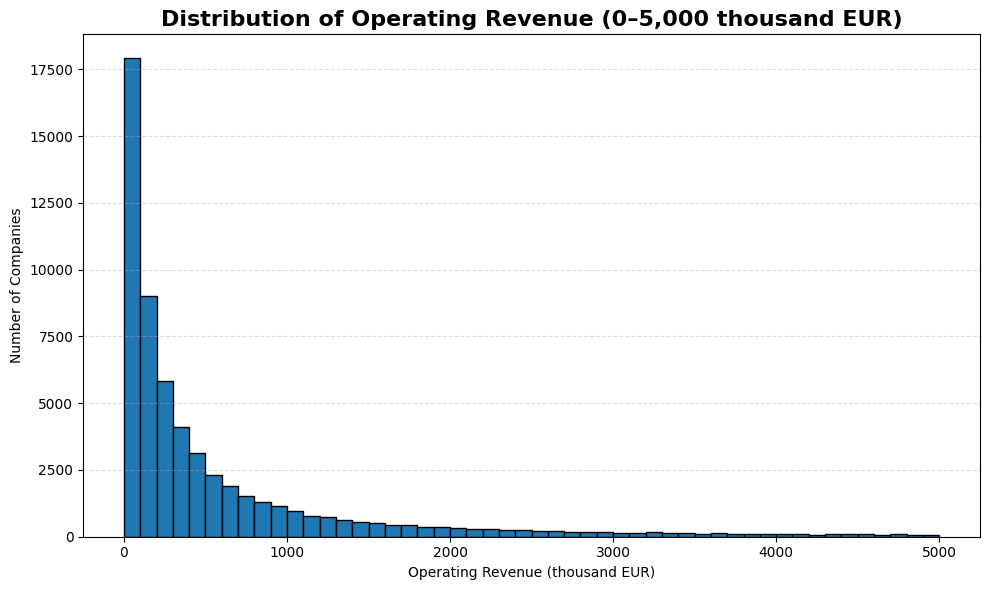

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Operating revenue (thousand EUR)"].dropna(),
    bins=50,
    range=(0,5000),
    edgecolor="black"
)

plt.title(
    "Distribution of Operating Revenue (0–5,000 thousand EUR)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Operating Revenue (thousand EUR)")
plt.ylabel("Number of Companies")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The histogram shows that most companies report relatively low operating revenues, while the number of companies decreases as operating revenue increases. This indicates that the distribution of operating revenue is highly right-skewed, with a large proportion of companies generating modest revenues and a small number of companies reporting substantially higher revenues.

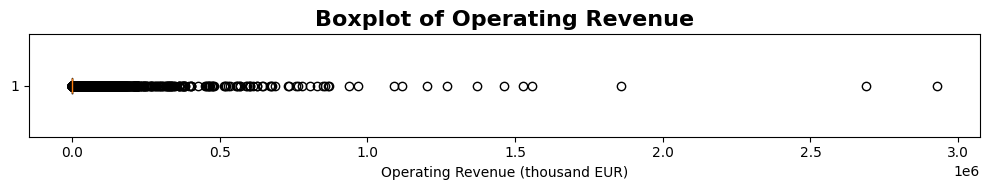

In [32]:
plt.figure(figsize=(10,2))

plt.boxplot(
    df["Operating revenue (thousand EUR)"].dropna(),
    vert=False
)

plt.title(
    "Boxplot of Operating Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Operating Revenue (thousand EUR)")

plt.tight_layout()

plt.show()

### Interpretation

The boxplot shows that most companies have relatively low operating revenues, while a small number of companies report exceptionally high revenues. These extreme values appear as outliers, indicating substantial differences in the financial size of companies within the dataset.

## 4.7 Importer / Exporter Status

This section analyses the distribution of companies according to their import and export activities.

In [33]:
# ==========================================
# Importer / Exporter
# ==========================================

trade = df["Importer / Exporter"].value_counts()

trade_summary = pd.DataFrame({
    "Number of Companies": trade,
    "Percentage (%)": round(trade / len(df) * 100, 2)
})

trade_summary

,Number of Companies,Percentage (%)
Importer / Exporter,,
No realiza actividad exterior,66002,90.55
Importador / Exportador,3486,4.78
Exportador,2302,3.16
Importador,1097,1.51


### Interpretation

The results indicate that the vast majority of companies (90.55%) do not engage in international trade activities. Among the companies involved in international markets, those operating as both importers and exporters represent the largest group, followed by exporters and importers. Overall, only a small proportion of the companies in the dataset participate in international trade.

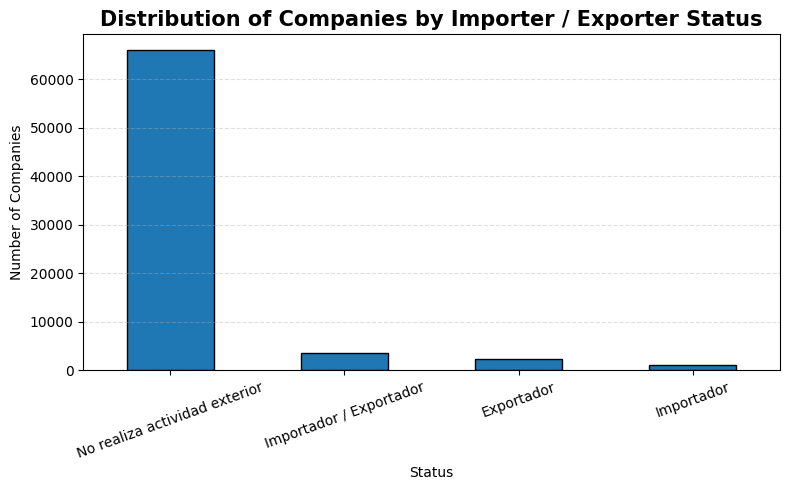

In [34]:
plt.figure(figsize=(8,5))

trade.plot(
    kind="bar",
    edgecolor="black"
)

plt.title(
    "Distribution of Companies by Importer / Exporter Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Status")
plt.ylabel("Number of Companies")

plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The bar chart shows that most companies (90.55%) do not participate in international trade activities. Among the companies involved in international trade, the largest group consists of companies that both import and export goods, followed by exporters and importers. Overall, international trade activities are carried out by only a small proportion of the companies in the dataset.

## 4.8 Stock Market Status

This section examines whether the companies are publicly listed or privately held.

In [35]:
stock = df["Stock Market Quote"].value_counts()

stock_summary = pd.DataFrame({
    "Number of Companies": stock,
    "Percentage (%)": round(stock / len(df) * 100, 2)
})

stock_summary

,Number of Companies,Percentage (%)
Stock Market Quote,,
No Cotiza en Bolsa,72883,99.99
Cotiza en Bolsa,4,0.01


### Interpretation

The results show that almost all companies in the dataset are privately held, with 99.99% of companies not listed on the stock market. Only four companies are publicly listed, indicating that publicly traded companies represent a very small proportion of the Spanish agri-food sector included in the dataset.

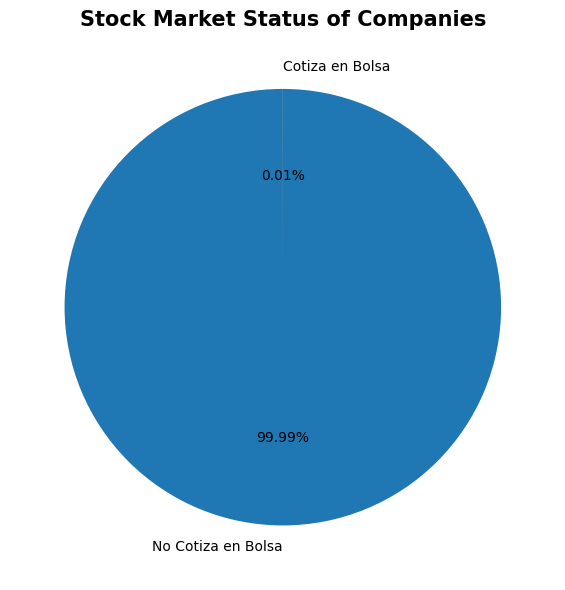

In [36]:
plt.figure(figsize=(6,6))

stock.plot(
    kind="pie",
    autopct='%1.2f%%',
    startangle=90
)

plt.ylabel("")
plt.title(
    "Stock Market Status of Companies",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 4.9 Corporate Group Structure

This section examines the number of companies belonging to corporate groups, providing insight into the organizational structure of the companies included in the dataset.

In [37]:
# ==========================================
# Corporate Group Statistics
# ==========================================

df["Nb of companies in corporate group"].describe()

,Nb of companies in corporate group
count,72875.000000
mean,9.566449
std,1095.116612
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,170541.000000


### Interpretation

The descriptive statistics indicate that most companies do not belong to large corporate groups. The median number of companies in a corporate group is 0, meaning that at least half of the companies operate independently. However, the maximum value is extremely high (170,541 companies), indicating the presence of a few exceptionally large corporate groups that substantially increase the average.

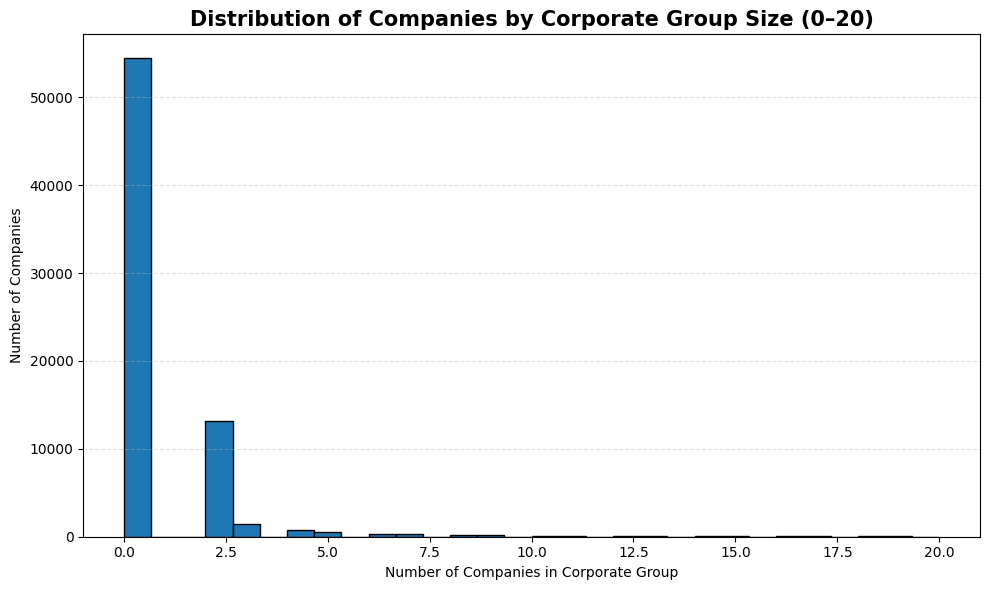

In [38]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Nb of companies in corporate group"].dropna(),
    bins=30,
    range=(0,20),
    edgecolor="black"
)

plt.title(
    "Distribution of Companies by Corporate Group Size (0–20)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Companies in Corporate Group")
plt.ylabel("Number of Companies")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Interpretation

The histogram shows that the majority of companies do not belong to a corporate group or belong to very small corporate groups. As the size of the corporate group increases, the number of companies decreases substantially. This indicates that large corporate groups are relatively uncommon within the dataset.

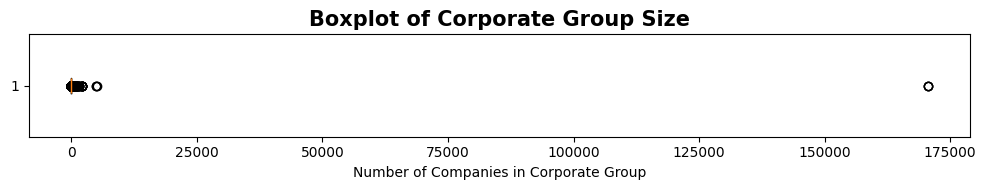

In [39]:
plt.figure(figsize=(10,2))

plt.boxplot(
    df["Nb of companies in corporate group"].dropna(),
    vert=False
)

plt.title(
    "Boxplot of Corporate Group Size",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Companies in Corporate Group")

plt.tight_layout()

plt.show()

### Interpretation

The boxplot indicates that most companies belong to very small corporate groups or operate independently. It also reveals the presence of several extreme outliers, representing companies that belong to exceptionally large corporate groups. These outliers illustrate the considerable variation in corporate group size across the dataset.

# 7. Conclusion

This notebook explored the sustainability characteristics of large Spanish agri-food companies using descriptive statistics, visualizations, and statistical comparisons.

The analysis showed that companies with sustainability-related documents tend to be larger in terms of both employee count and operating revenue. In addition, sustainability disclosure varies across economic sectors and geographical regions.

These findings provide the basis for the next stage of the internship, which focuses on analysing the textual content of sustainability-related documents using Natural Language Processing (NLP).